# Plot results for offline prompting in the "farm" example

In [ ]:
%cd ..
%pwd  # should be "llm-adaptation"

In [2]:
from pathlib import Path
import pandas as pd
import shutil
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FixedFormatter, FixedLocator
import numpy as np
import seaborn as sns
import os

In [18]:
results_folder = Path("generated_adaptations/dragon")
# results_folder = Path("generated_adaptations/old/251015/dragon")
pd.options.display.float_format = "{:,.1f}".format
sns.set_theme()

## Run experiments

In [4]:
prompts = {
    "default": "generated_adaptations/prompts_user/dragon_strategy.md",
    "reasons": "generated_adaptations/prompts_user/dragon_reasons.md",
}
variants = {
    "system": "system",
    "constraints": "all",
    # "stats": "stats",
    "result": "result",
}
llms = {
    # "5nanolow": "gpt-5-nano-2025-08-07,reasoning_effort=low",
    "5nano": "gpt-5-nano-2025-08-07",
    # "5mini": "gpt-5-mini-2025-08-07",
    # "5": "gpt-5-2025-08-07",
}
repeats = 1
start = 7

In [5]:
# import generated_adaptations.generator as generator

In [55]:
env = os.environ.copy()
env["PYTHONPATH"] = env.get("PYTHONPATH", "") + os.pathsep + os.getcwd()

for prompt_name, prompt in prompts.items():
    for variant, mode in variants.items():
        for llm_name, llm in llms.items():
            for repeat in range(start, start + repeats):
                folder_name = f"{llm_name}_{repeat:02d}"
                # print(f"\n{variant}/{folder_name}\n")
                # folder = results_folder / variant / folder_name
                print(f"\n{variant}_{prompt_name}/{folder_name}\n")
                folder = results_folder / f"{variant}_{prompt_name}" / folder_name
                folder.mkdir(parents=True, exist_ok=True)
                shutil.copy(prompt, folder / "01_user.md")
                cmd  = [sys.executable, "generated_adaptations/generator.py", f"--folder={str(folder)}", f"--llm={llm}", f"--mode={mode}"]
                result = subprocess.run(cmd, capture_output=True, text=True, env=env)  # even capture_output=False does not stream in real-time, so we rather capture it and print it later
                print(result.stdout)
                print(result.stderr)
                # generator.main([f"--folder={str(folder)}"])  # this also does not show the real-time output


system_default/5nano_07

Loaded 2 messages from generated_adaptations\dragon\system_default\5nano_07.
Querying LLM with prompt 01_user.
TOKENS USED:
Input: 1080, Output: 7320 (reasoning: 6336)
Response time (seconds): 62.5

LLM response saved to '02_llm.md'.
Code block saved to 'generated_adaptations\dragon\system_default\5nano_07\code_02.py'.
Running tests (system): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=dragon --adaptation_name=5nano_07/code_02 --variant=system_default --tests=system
Test exit code: 0
Running tests (functional): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=dragon --adaptation_name=5nano_07/code_02 --variant=system_default --tests=functional
Test exit code: 1
Running tests (all): pytest generated_adaptations/tests -q --tb=short -rfExX --show-capture=no --color=no --example=dragon --adaptation_name=5nano_07/code_02 --variant=system_default --tests=all
Test exit co

## Results

In [4]:
# folders = list(results_folder.glob("*/*"))
# folders = list(results_folder.glob("*/5nano_*"))
folders = list(results_folder.glob("*_*/5nano_*"))
# folders = list(results_folder.glob("*/5nanolow*"))
# folders = [results_folder / "41mini"]
print([(f.parent.stem, f.stem) for f in folders])

[('constraints_default', '5nano_01'), ('constraints_default', '5nano_02'), ('constraints_default', '5nano_03'), ('constraints_default', '5nano_04'), ('constraints_default', '5nano_05'), ('constraints_default', '5nano_06'), ('constraints_default', '5nano_07'), ('constraints_default', '5nano_08'), ('constraints_default', '5nano_09'), ('constraints_default', '5nano_10'), ('constraints_reasons', '5nano_01'), ('constraints_reasons', '5nano_02'), ('constraints_reasons', '5nano_03'), ('constraints_reasons', '5nano_04'), ('constraints_reasons', '5nano_05'), ('constraints_reasons', '5nano_06'), ('constraints_reasons', '5nano_07'), ('constraints_reasons', '5nano_08'), ('constraints_reasons', '5nano_09'), ('constraints_reasons', '5nano_10'), ('result_default', '5nano_01'), ('result_default', '5nano_02'), ('result_default', '5nano_03'), ('result_default', '5nano_04'), ('result_default', '5nano_05'), ('result_default', '5nano_06'), ('result_default', '5nano_07'), ('result_default', '5nano_08'), ('r

In [5]:
summary = pd.DataFrame(columns=["llm", "params", "repeat"])

for folder in folders:
    llm, repeat = folder.stem.split("_")
    params = folder.parent.stem
    summary.loc[len(summary), ["llm", "params", "repeat"]] = [llm, params, repeat]

    for file in (folder / "results").glob("*.txt"):
        name = file.stem.removeprefix("code_")
        code = name.split("_")[0]
        if "_missing" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "missing"
        elif "_system_fail" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "fail"
        elif "_system_pass" in name:
            summary.loc[len(summary) - 1, code + "_system"] = "pass"
        elif "_all_fail" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "fail"
        elif "_all_pass" in name:
            summary.loc[len(summary) - 1, code + "_all"] = "pass"
        elif "_functional_fail" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "fail"
        elif "_functional_pass" in name:
            summary.loc[len(summary) - 1, code + "_functional"] = "pass"
        else:
            print(f"Unknown file: {file}")
    for file in (folder / "results").glob("*.json"):
        name = file.stem.removeprefix("code_")
        if "_simulation_result" in name:
            code = name.removesuffix("_simulation_result")
            results = json.load(open(file))
            # result = results["winrate"]
            result = results["steps"]
            if result is None:
                # result = "-"
                result = 30 + results.get("dragon_hp", 0) / 2.5  # penalize remaining HP
            summary.loc[len(summary) - 1, code + "_result"] = result
        else:
            print(f"Unknown file: {file}")

summary = summary.astype("object")
summary.fillna("", inplace=True)

In [6]:
summary.set_index(["llm", "params", "repeat"], inplace=True)

In [7]:
summary = summary.reindex(sorted(summary.columns), axis=1)

In [8]:
summary

02_all 02_functional 02_result 02_system  \
llm   params              repeat                                            
5nano constraints_default 01       fail          fail      42.8      pass   
                          02       fail          fail      42.8      pass   
                          03       pass          pass      10.7      pass   
                          04       fail          fail      42.8      pass   
                          05       fail          pass      14.0      fail   
                          06       fail          fail      42.8      pass   
                          07       fail          fail      42.8      pass   
                          08       fail          pass      14.0      fail   
                          09       pass          pass      10.7      pass   
                          10       fail          fail      42.8      pass   
      constraints_reasons 01       fail          fail                fail   
                          02       fail          fail      42.8      fail   
                          03       fail          fail      42.8      pass   
                          04       pass          pass      11.0      pass   
                          05       pass          pass      12.7      pass   
                          06       fail          fail      42.8      fail   
                          07       fail          fail      42.8      fail   
                          08       fail          fail      42.8      fail   
                          09       pass          pass      15.3      pass   
                          10       fail          fail      42.8      fail   
      result_default      01       fail          fail      42.8      pass   
                          02       fail          fail      42.8      pass   
                          03       fail          fail      42.8      pass   
                          04       fail          fail      42.8      pass   
                          05       fail          fail      42.8      pass   
                          06       fail          fail      42.8      pass   
                          07       fail          fail      42.8      pass   
                          08       fail          fail      42.8      fail   
                          09       fail          fail      42.8      pass   
                          10       fail          fail      42.8      pass   
      result_reasons      01       pass          pass      10.7      pass   
                          02       pass          pass      16.0      pass   
                          03       fail          pass      14.0      fail   
                          04       fail          fail      42.8      fail   
                          05       pass          pass      11.0      pass   
                          06       fail          fail      50.0      fail   
                          07       fail          pass      14.0      fail   
                          08       fail          pass      14.0      fail   
                          09       pass          pass      15.3      pass   
                          10       pass          pass      10.7      pass   
      system_default      01       fail          fail      42.8      pass   
                          02       fail          fail      42.8      pass   
                          03       fail          pass      14.0      fail   
                          04       fail          fail      42.8      pass   
                          05       fail          fail      42.8      pass   
                          06       fail          fail      42.8      pass   
                          07       fail          fail      42.8      pass   
                          08       fail          fail      42.8      fail   
                          09       pass          pass      10.7      pass   
                          10       fail          fail      42.8      pass   
      system_reasons      01 

### Plot

In [9]:
colors = {
    "5nano/constraints_default": "tab:blue",
    "5nano/system_default": "tab:green",
    "5nano/result_default": "tab:orange",
    # "5nano/stats": "tab:red",
    "5nano/constraints_reasons": "tab:cyan",
    "5nano/system_reasons": "tab:olive",
    "5nano/result_reasons": "tab:brown",
}

In [10]:
result_cols = [col for col in summary.columns if col.endswith("_result")]
# plot_data = summary[result_cols].replace({"-": 30, "": np.nan}).astype(float)
plot_data = summary[result_cols].replace({"-": 35, "": np.nan}).astype(float)
plot_data

C:\Users\micha\AppData\Local\Temp\ipykernel_37740\3704091001.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_data = summary[result_cols].replace({"-": 35, "": np.nan}).astype(float)


02_result  04_result  06_result  08_result  \
llm   params              repeat                                               
5nano constraints_default 01           42.8       10.7        NaN        NaN   
                          02           42.8       10.7        NaN        NaN   
                          03           10.7        NaN        NaN        NaN   
                          04           42.8       42.8       10.7        NaN   
                          05           14.0       42.8       42.8       11.0   
                          06           42.8       10.7        NaN        NaN   
                          07           42.8       10.7        NaN        NaN   
                          08           14.0       14.0        NaN        NaN   
                          09           10.7        NaN        NaN        NaN   
                          10           42.8       10.7        NaN        NaN   
      constraints_reasons 01            NaN       42.8       10.7        NaN   
                          02           42.8       42.8       10.7        NaN   
                          03           42.8       10.7        NaN        NaN   
                          04           11.0        NaN        NaN        NaN   
                          05           12.7        NaN        NaN        NaN   
                          06           42.8       14.0       14.0        NaN   
                          07           42.8       42.8       14.0        NaN   
                          08           42.8       10.7        NaN        NaN   
                          09           15.3       10.0       11.0        NaN   
                          10           42.8       14.0       14.0        NaN   
      result_default      01           42.8       10.7        NaN        NaN   
                          02           42.8       42.8       42.8       13.3   
                          03           42.8       10.0       10.7        NaN   
                          04           42.8       10.7        NaN        NaN   
                          05           42.8       42.8       10.7        NaN   
                          06           42.8       42.8        NaN       42.8   
                          07           42.8       10.7        NaN        NaN   
                          08           42.8       42.8       10.7        NaN   
                          09           42.8       42.8       42.8       42.8   
                          10           42.8       12.0       12.3        NaN   
      result_reasons      01           10.7        NaN        NaN        NaN   
                          02           16.0       42.8       42.8       15.3   
                          03           14.0       10.0       10.7        NaN   
                          04           42.8       10.0       10.7        NaN   
                          05           11.0        NaN        NaN        NaN   
                          06           50.0       10.7        NaN        NaN   
                          07           14.0       10.7        NaN        NaN   
                          08           14.0       10.7        NaN        NaN   
                          09           15.3       16.3       10.7        NaN   
                          10           10.7        NaN        NaN        NaN   
      system_default      01           42.8       42.8       10.7        NaN   
                          02           42.8       40.8       40.8       40.8   
                          03           14.0       14.0        NaN        NaN   
                          04           42.8       10.7        NaN        NaN   
                          05           42.8       10.7        NaN        NaN   
                          06           42.8       42.8       42.8       50.0   
                          07           42.8       42.8       42.8       42.8   
                          08           42.8       14.0       14.0        NaN   
                          09      

In [11]:
stop_by_constraints = plot_data.copy()

def clear_after_pass(row):
    passed = False

    for col in row.index:
        if not passed:
            constraints_col = col.replace('_result', '_all')
            # constraints_col = col.replace('_result', '_functional')
            if summary.loc[row.name, constraints_col] == "pass":
                passed = True
        else:
            row[col] = np.nan
    return row

stop_by_constraints = stop_by_constraints.apply(clear_after_pass, axis=1)
plot_data = stop_by_constraints
stop_by_constraints

02_result  04_result  06_result  08_result  \
llm   params              repeat                                               
5nano constraints_default 01           42.8       10.7        NaN        NaN   
                          02           42.8       10.7        NaN        NaN   
                          03           10.7        NaN        NaN        NaN   
                          04           42.8       42.8       10.7        NaN   
                          05           14.0       42.8       42.8       11.0   
                          06           42.8       10.7        NaN        NaN   
                          07           42.8       10.7        NaN        NaN   
                          08           14.0       14.0        NaN        NaN   
                          09           10.7        NaN        NaN        NaN   
                          10           42.8       10.7        NaN        NaN   
      constraints_reasons 01            NaN       42.8       10.7        NaN   
                          02           42.8       42.8       10.7        NaN   
                          03           42.8       10.7        NaN        NaN   
                          04           11.0        NaN        NaN        NaN   
                          05           12.7        NaN        NaN        NaN   
                          06           42.8       14.0       14.0        NaN   
                          07           42.8       42.8       14.0        NaN   
                          08           42.8       10.7        NaN        NaN   
                          09           15.3        NaN        NaN        NaN   
                          10           42.8       14.0       14.0        NaN   
      result_default      01           42.8       10.7        NaN        NaN   
                          02           42.8       42.8       42.8       13.3   
                          03           42.8       10.0       10.7        NaN   
                          04           42.8       10.7        NaN        NaN   
                          05           42.8       42.8       10.7        NaN   
                          06           42.8       42.8        NaN       42.8   
                          07           42.8       10.7        NaN        NaN   
                          08           42.8       42.8       10.7        NaN   
                          09           42.8       42.8       42.8       42.8   
                          10           42.8       12.0       12.3        NaN   
      result_reasons      01           10.7        NaN        NaN        NaN   
                          02           16.0        NaN        NaN        NaN   
                          03           14.0       10.0       10.7        NaN   
                          04           42.8       10.0       10.7        NaN   
                          05           11.0        NaN        NaN        NaN   
                          06           50.0       10.7        NaN        NaN   
                          07           14.0       10.7        NaN        NaN   
                          08           14.0       10.7        NaN        NaN   
                          09           15.3        NaN        NaN        NaN   
                          10           10.7        NaN        NaN        NaN   
      system_default      01           42.8       42.8       10.7        NaN   
                          02           42.8       40.8       40.8       40.8   
                          03           14.0       14.0        NaN        NaN   
                          04           42.8       10.7        NaN        NaN   
                          05           42.8       10.7        NaN        NaN   
                          06           42.8       42.8       42.8       50.0   
                          07           42.8       42.8       42.8       42.8   
                          08           42.8       14.0       14.0        NaN   
                          09      

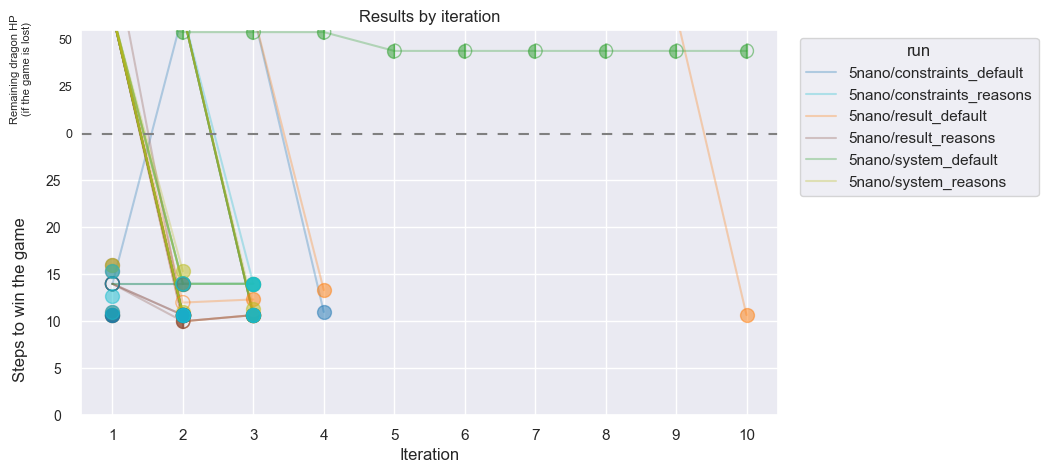

In [12]:
plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(orig_cols, labels):
    y = plot_df[col].values
    # draw the line for the run
    label_no_repeat = label.rsplit("/", 1)[0]
    if label_no_repeat not in colors:
        continue

    color = colors[label_no_repeat]
    if label_no_repeat in ax.get_legend_handles_labels()[1]:
        label_no_repeat = None
    line, = ax.plot(x, y, '-', label=label_no_repeat, alpha=0.3, color=color)

    # collect indices by test status
    pass_idx, half_idx, fail_idx = [], [], []
    for i, result_col in enumerate(plot_df.index):  # e.g. '02_result'
        system_col = result_col.replace('_result', '_system')
        functional_col = result_col.replace('_result', '_functional')
        all_col = result_col.replace('_result', '_all')

        system = summary.loc[col, system_col]
        functional = summary.loc[col, functional_col] if functional_col in summary.columns else summary.loc[col, all_col]

        if system == "pass" and functional == "pass":
            pass_idx.append(i)
        elif system == "pass":
            half_idx.append(i)
        else:
            fail_idx.append(i)

    # overplot markers (use same color as the line)
    scatter_kwargs = {
        "zorder": 5 if "constraints" in label else 3,
        "s": 100, "alpha": 0.5
    }
    if pass_idx:
        ax.scatter([x[i] for i in pass_idx], [y[i] for i in pass_idx], marker='o', color=color, **scatter_kwargs)
    if half_idx:
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="left"), color=color, **scatter_kwargs)
        ax.scatter([x[i] for i in half_idx], [y[i] for i in half_idx], marker=MarkerStyle("o", fillstyle="right"), color="none", edgecolors=color, **scatter_kwargs)
    if fail_idx:
        ax.scatter([x[i] for i in fail_idx], [y[i] for i in fail_idx], marker='o', color=color, facecolors='none', **scatter_kwargs)

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Iteration")

# y axis
xlim = ax.get_xlim()
ax.plot(xlim, [30, 30], linestyle=(0, (5, 5)), c='gray')
ax.set_xlim(xlim)
major_ticks = list(range(0, 30, 5))
minor_ticks = [30, 35, 40]
ax.set_ylim(0, 41)
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)
ax.set_yticklabels([str(t) for t in major_ticks])
ax.yaxis.set_minor_formatter(FixedFormatter([str((t - 30) * 5) for t in minor_ticks]))
ax.tick_params(axis='y', which='major', length=8, width=1.2, labelsize=10, pad=6)
ax.tick_params(axis='y', which='minor', length=4, width=1.0, labelsize=9, pad=2, labelbottom=True)
ax.text(-0.3, 0.3, "Steps to win the game", transform=ax.get_xaxis_transform(), rotation=90, ha='center', va='center', fontsize=12)
ax.text(-0.3, 0.9, "Remaining dragon HP\n(if the game is lost)", transform=ax.get_xaxis_transform(), rotation=90, ha='center', va='center', fontsize=8)
# ax.set_ylabel("Result (steps)")

ax.set_title("Results by iteration")
ax.legend(title="run", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
plt.show()

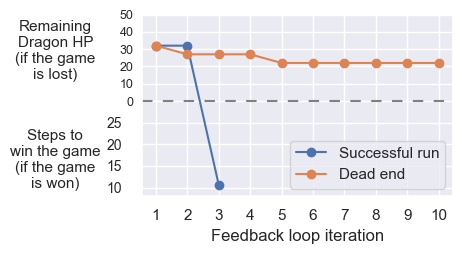

In [13]:
# cherrypick two runs for the paper

plot_df = plot_data.T.copy()  # index: result columns like `02_result`, columns: MultiIndex (llm, params, repeat)
orig_cols = plot_df.columns  # MultiIndex
labels = [f"{llm}/{params}/{repeat}" for llm, params, repeat in orig_cols]
x = list(range(1, len(plot_df.index) + 1))

label_titles = {
    "5nano/system_default/02": "Dead end",
    "5nano/constraints_reasons/02":"Successful run",
}

fig, ax = plt.subplots(figsize=(5, 2.7))
for col, label in zip(orig_cols, labels):
    if label not in label_titles:
        continue
    y = plot_df[col].values
    line, = ax.plot(x, y, 'o-', label=label_titles[label])

# finalize axes
ax.set_xticks(x)
ax.set_xticklabels(x)  # iterations 1,2,3,...
ax.set_xlabel("Feedback loop iteration")

# y axis
xlim = ax.get_xlim()
ax.plot(xlim, [30, 30], linestyle=(0, (5, 5)), c='gray')
ax.set_xlim(xlim)
major_ticks = list(range(10, 30, 5))
minor_ticks = [30, 34, 38, 42, 46, 50]
ax.set_ylim(8, 50)
ax.set_yticks(major_ticks)
ax.set_yticks(minor_ticks, minor=True)
ax.set_yticklabels([str(t) for t in major_ticks])
ax.yaxis.set_minor_formatter(FixedFormatter([f"{(t - 30) * 2.5:.0f}" for t in minor_ticks]))
ax.tick_params(axis='y', which='major', length=8, width=1.2, labelsize=10, pad=6)
ax.tick_params(axis='y', which='minor', length=4, width=1.0, labelsize=9, pad=2, labelbottom=True)
ax.grid(True, which='minor', axis='y')
ax.text(-2.2, 0.2, "Steps to\nwin the game\n(if the game\nis won)", transform=ax.get_xaxis_transform(), rotation=0, ha='center', va='center', fontsize=11)
ax.text(-2.2, 0.8, "Remaining\nDragon HP\n(if the game\nis lost)", transform=ax.get_xaxis_transform(), rotation=0, ha='center', va='center', fontsize=11)
# ax.set_ylabel("Result (steps)")

# ax.set_title("System metrics by feedback loop iteration")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(results_folder / "dead_end.pdf", bbox_inches="tight")
plt.show()

### Iteration counts

In [14]:
def last_value_index(row):
    last_index = 0
    for i, col in enumerate(row.index, start=1):
        if not np.isnan(row[col]):
            last_index = i
    return last_index

iterations = plot_data.apply(last_value_index, axis=1)
iterations = pd.DataFrame(iterations).rename(columns={0: "iterations"})
iterations = iterations.reset_index()
iterations

,llm,params,repeat,iterations
0,5nano,constraints_default,01,2
1,5nano,constraints_default,02,2
2,5nano,constraints_default,03,1
3,5nano,constraints_default,04,3
4,5nano,constraints_default,05,4
5,5nano,constraints_default,06,2
6,5nano,constraints_default,07,2
7,5nano,constraints_default,08,2
8,5nano,constraints_default,09,1
9,5nano,constraints_default,10,2


<Axes: xlabel='iterations', ylabel='params'>

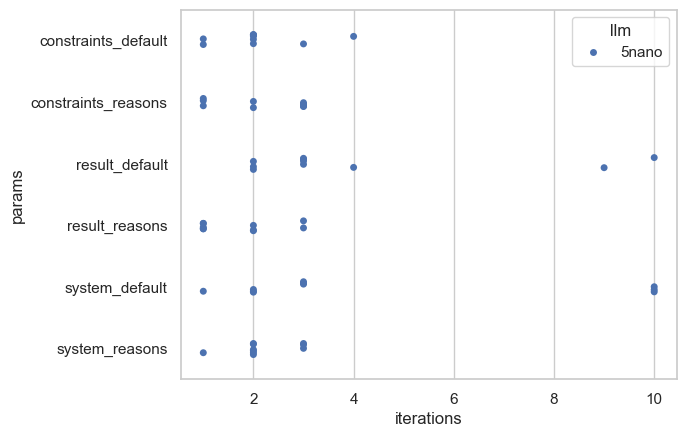

In [15]:
sns.stripplot(x="iterations", y="params", hue="llm", data=iterations, dodge=True)

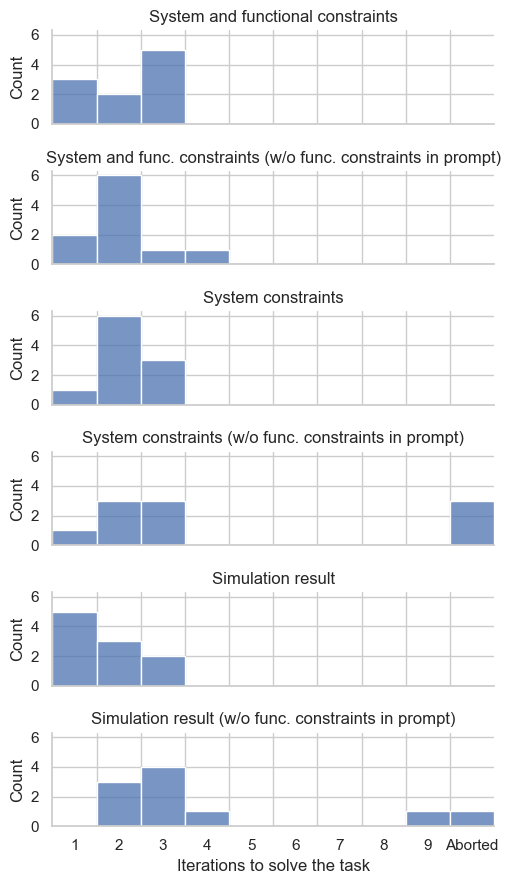

In [16]:
label_map = {
    "constraints_reasons": "System and functional constraints",
    "constraints_default": "System and func. constraints (w/o func. constraints in prompt)",
    "system_reasons": "System constraints",
    "system_default": "System constraints (w/o func. constraints in prompt)",
    "result_reasons": "Simulation result",
    "result_default": "Simulation result (w/o func. constraints in prompt)",
}
iterations["params_label"] = iterations["params"].map(label_map)

g = sns.FacetGrid(iterations, row="params_label", hue="llm", sharex=True, height=1.5, aspect=3.5, xlim=(0.5, 10.5), row_order=list(label_map.values()))
g.map(sns.histplot, "iterations", multiple="dodge", bins=np.arange(0.5, 11, 1))
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 11), labels=list(range(1, 10)) + ["Aborted"])
    ax.set_yticks(range(0, 7, 2))

    # minor ticks for grid lines between bars
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(1.5, 10.5, 1)))
    ax.tick_params(axis='x', which='minor', length=0)
    ax.grid(False, which='major', axis='x')
    ax.grid(True, which='minor', axis='x')

g.set_titles(row_template="{row_name}")
g.set_xlabels("Iterations to solve the task")

g.tight_layout()
plt.savefig(results_folder / "dragon_hist_long.pdf", bbox_inches="tight")
plt.show()

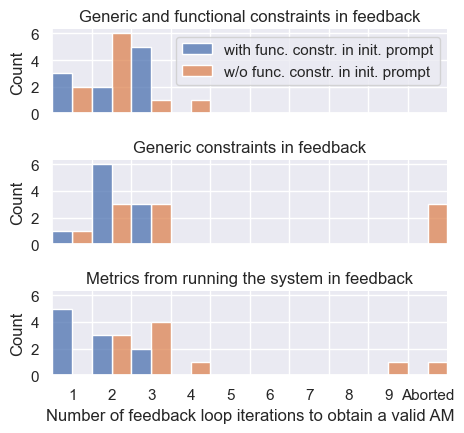

In [20]:
iterations[["variant", "prompt"]] = iterations["params"].str.split("_", expand=True)
variant_labels = {
    "constraints": "Generic and functional constraints in feedback",
    "system": "Generic constraints in feedback",
    "result": "Metrics from running the system in feedback",
}
prompt_labels = {
    "reasons": "with func. constr. in init. prompt",
    "default": "w/o func. constr. in init. prompt",
}
iterations["variant_label"] = iterations["variant"].map(variant_labels)
iterations["prompt_label"] = iterations["prompt"].map(prompt_labels)

g = sns.displot(iterations, x="iterations", row="variant_label", hue="prompt_label", multiple="dodge", bins=np.arange(0.5, 11, 1), height=1.5, aspect=3.2, facet_kws={"legend_out": False, "xlim": (0.5, 10.5)}, row_order=list(variant_labels.values()), hue_order=list(prompt_labels.values()))
for ax in g.axes.flatten():
    ax.set_xticks(range(1, 11), labels=list(range(1, 10)) + ["Aborted"])
    ax.set_yticks(range(0, 7, 2))

    # minor ticks for grid lines between bars
    ax.xaxis.set_minor_locator(FixedLocator(np.arange(1.5, 10.5, 1)))
    ax.tick_params(axis='x', which='minor', length=0)
    ax.grid(False, which='major', axis='x')
    ax.grid(True, which='minor', axis='x')

g.set_titles(row_template="{row_name}")
g.set_xlabels("Number of feedback loop iterations to obtain a valid AM")
g._legend.set_title("")

g.tight_layout()
plt.savefig(results_folder / "dragon_hist.pdf", bbox_inches="tight")
plt.show()